## Importing Libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import os
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler

## Loading the Dataset

In [18]:
data = pd.read_csv('/content/drive/MyDrive/Projects/Stock Price Prediction/all_stocks_5yr.csv')
data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [19]:
data.shape

(619040, 7)

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


#### Whenever we deal with the date or time feature, it should always be in the DateTime data type.

In [21]:
data["date"] = pd.to_datetime(data["date"])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[ns]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 33.1+ MB


## Exploratory Data Analysis

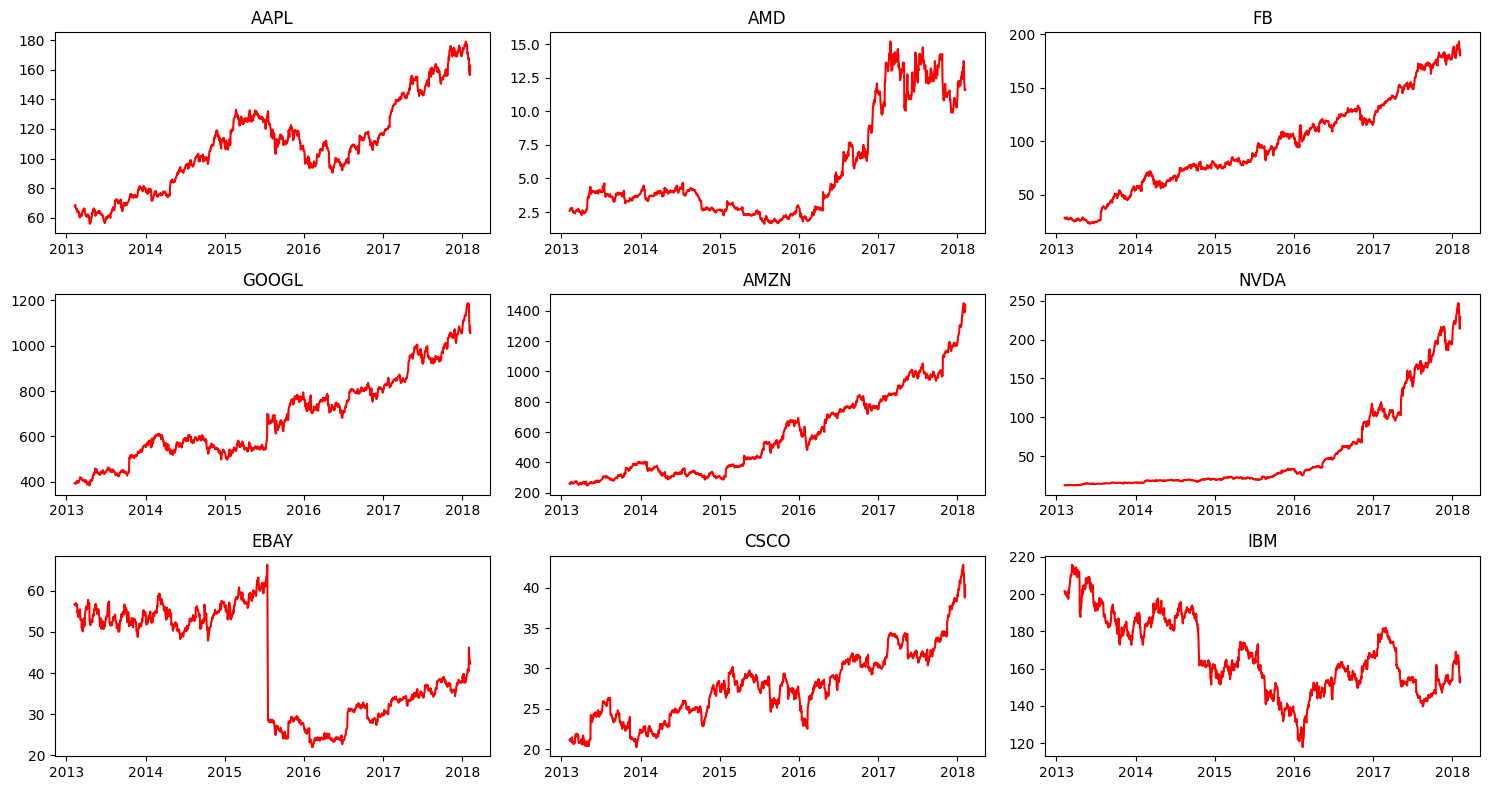

In [22]:
companies = ['AAPL', 'AMD', 'FB', 'GOOGL', 'AMZN', 'NVDA', 'EBAY', 'CSCO', 'IBM']

plt.figure(figsize=(15, 8))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = data[data['Name'] == company]
    plt.plot(c['date'], c['close'], c="r", label="close")
    plt.title(company)
    plt.tight_layout()

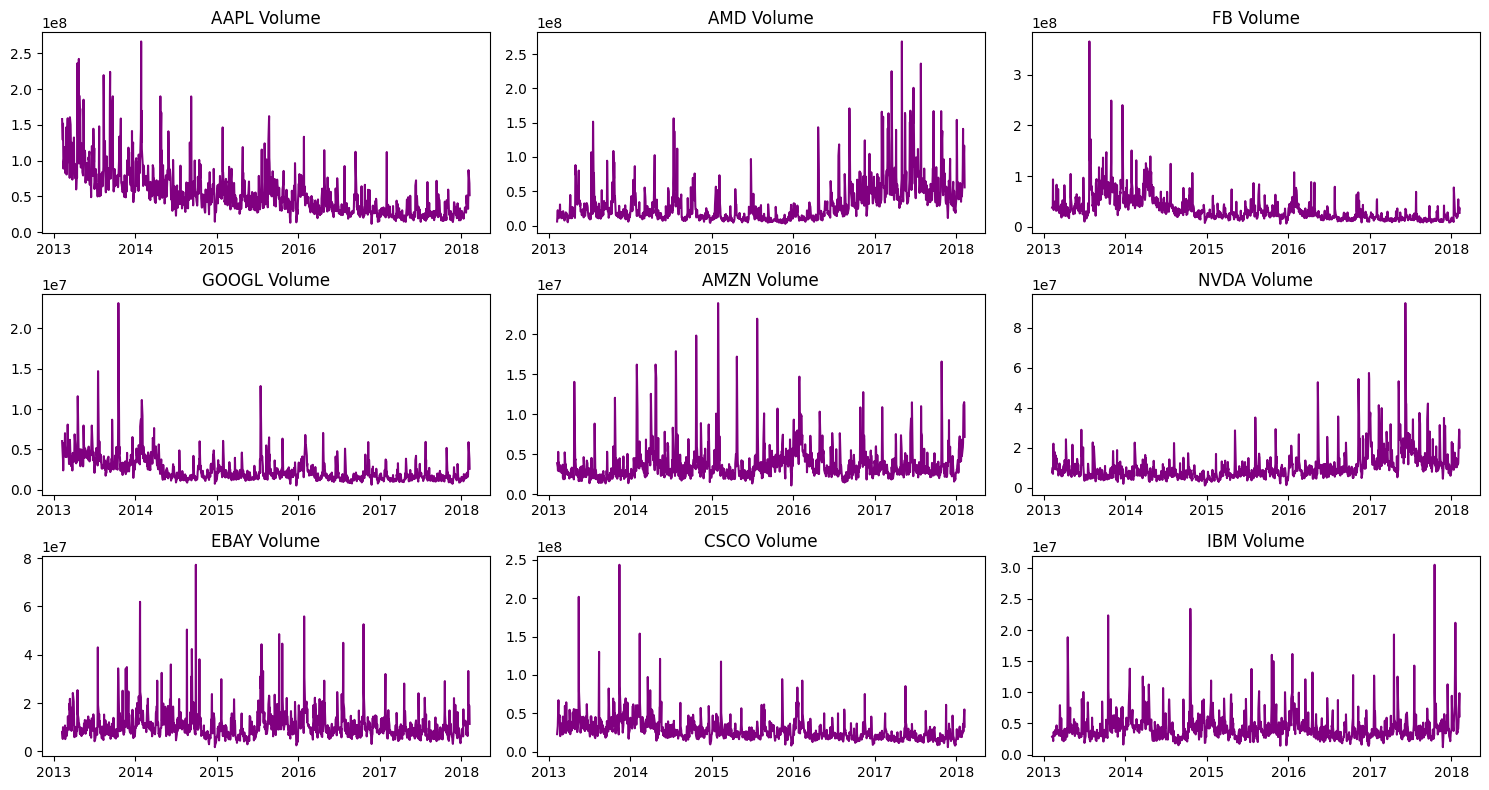

In [23]:
plt.figure(figsize=(15, 8))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = data[data['Name'] == company]
    plt.plot(c['date'], c['volume'], c='purple')
    plt.title(f"{company} Volume")
    plt.tight_layout()

#### Now let's analyze the data for Apple Stocks from 2013 to 2018

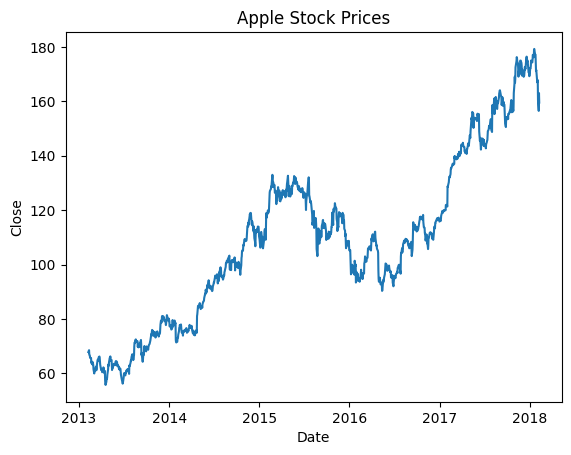

In [24]:
apple = data[data['Name'] == 'AAPL']

prediction_range = apple.loc[(apple['date'] > datetime(2013,1,1)) & (apple['date'] < datetime(2018,1,1))]

plt.plot(apple['date'],apple['close'])
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Apple Stock Prices")
plt.show()

#### select a subset of the whole data as the training data

In [25]:
close_data = apple['close'].values
close_data = close_data.reshape(-1, 1)
training = int(np.ceil(len(close_data) * .95))
print(training)

1197


## Prepare Feature and Labels

In [26]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_data.reshape(-1, 1))
train_data = scaled_data[0:int(training), :]

x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [27]:
x_train.shape

(1137, 60, 1)

## Build LSTM network using TensorFlow

In [28]:
model = keras.models.Sequential()
model.add(keras.layers.Input(shape=(x_train.shape[1], 1)))
model.add(keras.layers.LSTM(units=64, return_sequences=True))
model.add(keras.layers.LSTM(units=64))
model.add(keras.layers.Dense(32))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(1))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

## Model Compilation and Training

In [29]:
model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(x_train, y_train, epochs=10)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0418
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0096
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0093
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0088
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0076
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0057
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0059
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0060
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0061
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0067


## Prepare Test Data and Predictions

In [30]:
test_data = scaled_data[training - 60:, :]

x_test = []
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

y_test = close_data[training:, :]

pred = model.predict(x_test)
pred = scaler.inverse_transform(pred)

mse  = np.mean((pred - y_test) ** 2)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step
MSE: 26.341855287438538
RMSE: 5.13243171288606


## Visualize the Final Results

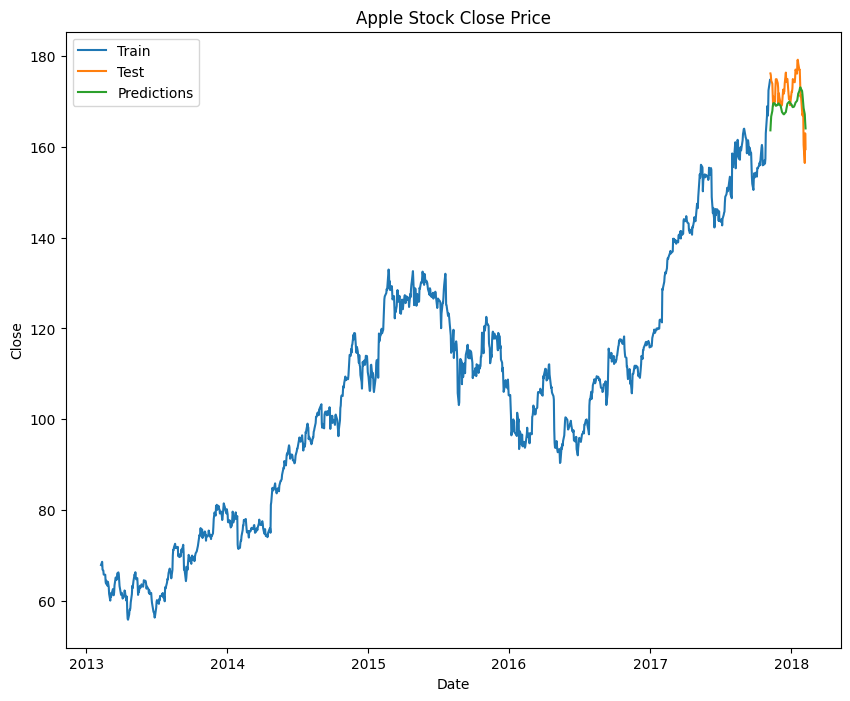

In [31]:
train = apple.iloc[:training].copy()
test  = apple.iloc[training:].copy()
test['Predictions'] = pred

plt.figure(figsize=(10, 8))
plt.plot(train['date'], train['close'])
plt.plot(test['date'], test[['close', 'Predictions']])
plt.title('Apple Stock Close Price')
plt.xlabel('Date')
plt.ylabel("Close")
plt.legend(['Train', 'Test', 'Predictions'])